# Movie Success Analysis

This notebook includes the main data loading, EDA, hypothesis testing, and machine learning results for my DSA210 project.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [4]:
df = pd.read_excel("movies.xlsx")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (4806, 9)


,budget,genres,popularity,release_date,revenue,title,vote_average,vote_count,Correlation (Budget vs Revenue)
0,237000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",150437577.0,2009-12-10,2.787965e+09,Avatar,72.0,11800.0,0.705399
1,300000000.0,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",139082615.0,2007-05-19,9.610000e+08,Pirates of the Caribbean: At World's End,69.0,4500.0,0.710805
2,245000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",107376788.0,2015-10-26,8.806746e+08,Spectre,63.0,4466.0,0.708496
3,250000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",11231295.0,2012-07-16,1.084939e+09,The Dark Knight Rises,76.0,9106.0,0.706728
4,260000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",43926995.0,2012-03-07,2.841391e+08,John Carter,61.0,2124.0,0.704413


## Revenue vs Budget Relationship

This section examines whether movies with higher budgets also tend to generate higher revenues.

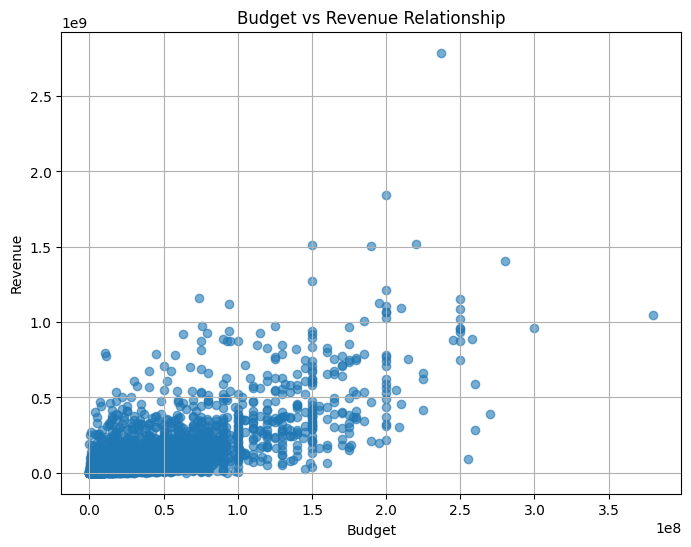

In [5]:
plt.figure(figsize=(8,6))

plt.scatter(df['budget'], df['revenue'], alpha=0.6)

plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Budget vs Revenue Relationship")

plt.grid(True)

plt.show()

### Revenue vs Budget Conclusion

The exploratory analysis suggests a positive relationship between movie budgets and revenues.

Movies with larger budgets generally tend to generate higher revenues, although several outliers and exceptions are also visible in the dataset.

## Correlation Matrix

This heatmap shows the relationships between numerical variables in the dataset.

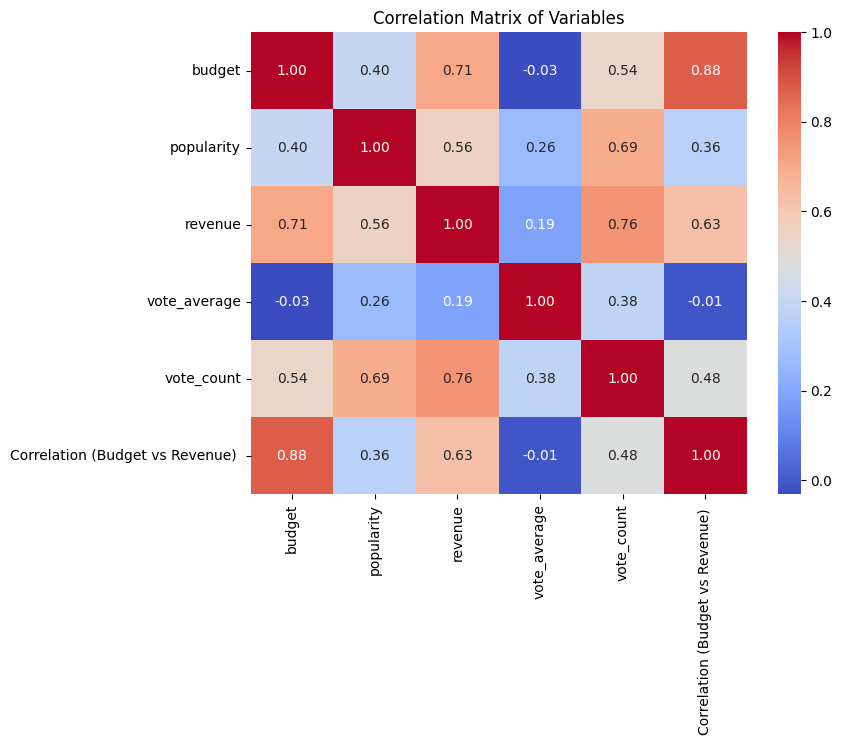

In [7]:
plt.figure(figsize=(8,6))

sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix of Variables")

plt.show()

### Correlation Matrix Conclusion

Correlation analysis shows that budget, revenue, and vote count are positively associated with each other.

The strongest relationships appear between revenue and vote count, as well as budget and revenue, suggesting that audience engagement and financial investment are important factors related to movie success.

## Hypothesis Testing

This section tests whether successful movies have significantly different revenues compared to unsuccessful movies.

In [8]:
from scipy.stats import ttest_ind

# Create success groups
successful = df[df['revenue'] > df['revenue'].median()]
unsuccessful = df[df['revenue'] <= df['revenue'].median()]

# Perform t-test
t_stat, p_value = ttest_ind(successful['revenue'],
                            unsuccessful['revenue'])

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

# Interpretation
if p_value < 0.05:
    print("There is a statistically significant difference.")
else:
    print("There is no statistically significant difference.")

T-Statistic: 36.72171036065806
P-Value: 5.551936529198844e-247
There is a statistically significant difference.


### Hypothesis Testing Conclusion

The hypothesis test indicates a statistically significant difference between successful and unsuccessful movies.

This suggests that the observed revenue differences are unlikely to be caused by random variation alone.

## Machine Learning Analysis

This section applies machine learning models to predict movie revenue and classify movie success. 

The analysis includes:
- Linear Regression
- Decision Tree Classification
- Cross-validation
- Hyperparameter tuning
- Feature importance analysis

The goal is to evaluate which variables are most strongly associated with movie success and determine how reliably the models perform across different data splits.

DATA LOADED
        budget                                             genres  \
0  237000000.0  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000.0  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000.0  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000.0  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000.0  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

    popularity release_date       revenue  \
0  150437577.0   2009-12-10  2.787965e+09   
1  139082615.0   2007-05-19  9.610000e+08   
2  107376788.0   2015-10-26  8.806746e+08   
3   11231295.0   2012-07-16  1.084939e+09   
4   43926995.0   2012-03-07  2.841391e+08   

                                      title  vote_average  vote_count  \
0                                    Avatar          72.0     11800.0   
1  Pirates of the Caribbean: At World's End          69.0      4500.0   
2                                   Spectre          63.0      4466.0   
3         

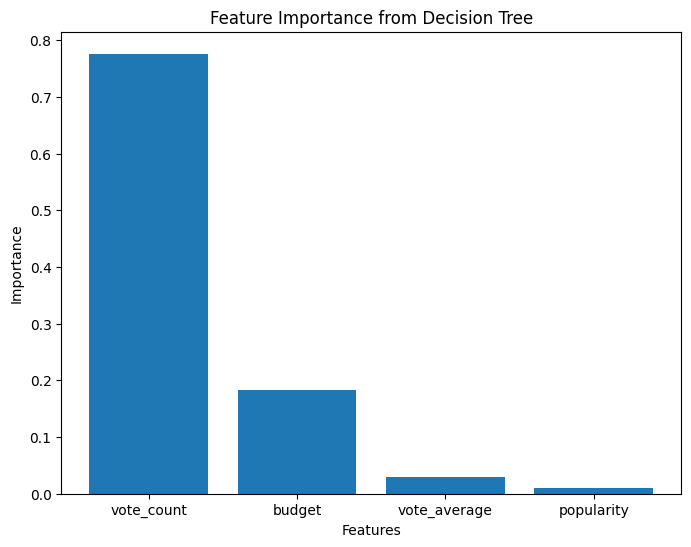

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score
)

import matplotlib.pyplot as plt


# LOAD DATA

df = pd.read_excel("movies.xlsx")

print("DATA LOADED")
print(df.head())


# SELECT VARIABLES

df = df[['budget', 'revenue', 'popularity', 'vote_average', 'vote_count']]


# CLEANING

df = df.dropna()
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

print("\nCLEANED DATA SHAPE:", df.shape)


# CREATE SUCCESS VARIABLE

df['success'] = (df['revenue'] > df['budget']).astype(int)


# =========================================================
# MODEL 1 — LINEAR REGRESSION
# =========================================================

X = df[['budget', 'popularity', 'vote_average', 'vote_count']]
y = df['revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

print("\nLINEAR REGRESSION RESULTS")
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


# =========================================================
# MODEL 2 — DECISION TREE CLASSIFICATION
# =========================================================

X = df[['budget', 'popularity', 'vote_average', 'vote_count']]
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

tree = DecisionTreeClassifier(max_depth=4)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

print("\nDECISION TREE RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred))


# =========================================================
# CROSS VALIDATION
# =========================================================

cv_scores = cross_val_score(tree, X, y, cv=5)

print("\nCROSS VALIDATION")
print("Scores:", cv_scores)
print("Average Score:", cv_scores.mean())


# =========================================================
# HYPERPARAMETER TUNING
# =========================================================

param_grid = {
    'max_depth': [2, 4, 6, 8, 10]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5
)

grid_search.fit(X_train, y_train)

print("\nHYPERPARAMETER TUNING")
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)


# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFEATURE IMPORTANCE")
print(importance)


# =========================================================
# FEATURE IMPORTANCE VISUALIZATION
# =========================================================

plt.figure(figsize=(8,6))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance from Decision Tree")

plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

### Machine Learning Conclusion

The machine learning models achieved moderate to strong predictive performance.

Cross-validation and hyperparameter tuning improved model reliability, while feature importance analysis showed that vote count and budget are among the strongest predictors of movie success.

## Genre Analysis

This section explores how movie genres relate to popularity and revenue.

main_genre
Animation          2.989416e+08
Adventure          2.460844e+08
Family             2.340616e+08
Science Fiction    2.047634e+08
Fantasy            1.834107e+08
Action             1.555427e+08
History            1.007775e+08
Thriller           9.904276e+07
Romance            9.892815e+07
Mystery            9.849483e+07
Name: revenue, dtype: float64


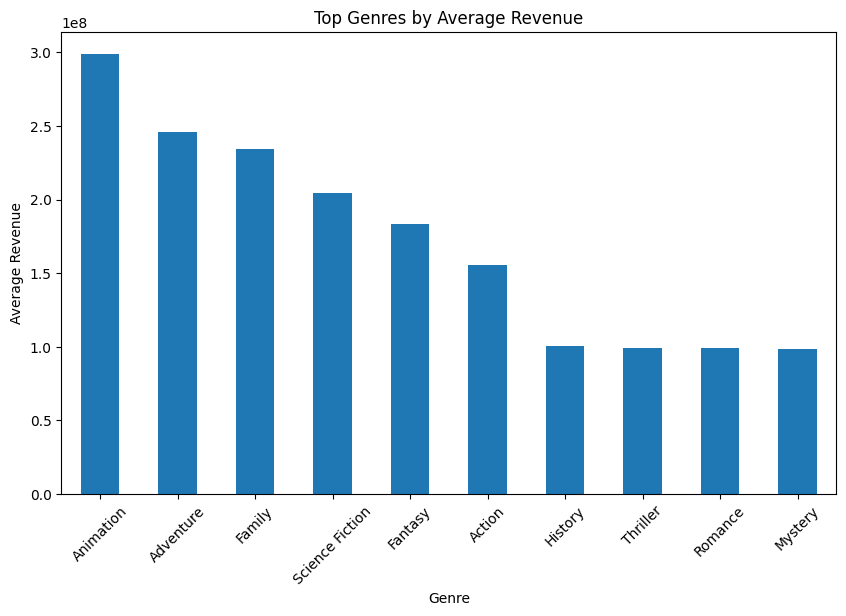

In [12]:
# Extract simplified genre names
df_genre = pd.read_excel("movies.xlsx")

df_genre['main_genre'] = (
    df_genre['genres']
    .astype(str)
    .str.extract(r'"name": "([^"]+)"')
)

# Average revenue by genre
genre_revenue = (
    df_genre.groupby('main_genre')['revenue']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(genre_revenue)

# Visualization
plt.figure(figsize=(10,6))

genre_revenue.plot(kind='bar')

plt.title("Top Genres by Average Revenue")
plt.xlabel("Genre")
plt.ylabel("Average Revenue")

plt.xticks(rotation=45)

plt.show()

### Genre Analysis Conclusion

Genre analysis suggests that some movie genres tend to generate higher average revenues than others.

Animation, Adventure, and Family movies appear among the highest-performing genres in the dataset.